# Inspeção Visual de Defeitos em Peças Industriais com CNNs e Transfer Learning

## 1. Introdução

**O Problema da Inspeção Visual Industrial**
Na manufatura moderna, garantir a qualidade das peças produzidas é fundamental. Tradicionalmente, a inspeção de defeitos em peças fundidas (casting) é feita manualmente por operadores, um processo suscetível à fadiga, variações de critério e lentidão.

**A Importância da Automação**
A automação utilizando Visão Computacional e Deep Learning permite analisar peças em tempo real na linha de produção, com alta precisão e padronização. Isso reduz custos, evita o descarte incorreto de peças boas e, principalmente, impede que peças defeituosas cheguem ao cliente final.

**Objetivo do Projeto**
Este projeto desenvolve um sistema de classificação binária de imagens para identificar se um impulsor de bomba submersível (peça de metal fundido) possui defeito ou está em perfeitas condições. Compararemos três estratégias:
1. **CNN treinada do zero:** Arquitetura própria desenvolvida para o problema.
2. **Feature Extraction (Transfer Learning):** Uso de um modelo pré-treinado (MobileNetV2) com camadas base congeladas.
3. **Fine-tuning:** Descongelamento e ajuste fino das camadas superiores do modelo pré-treinado.

**Classes do Dataset**
*   `def_front`: Peça com defeito (rachaduras, bolhas, rebarbas).
*   `ok_front`: Peça sem defeito.

## 2. Importação das Bibliotecas
Nesta etapa, importamos as ferramentas necessárias e fixamos as *seeds* para garantir a reprodutibilidade dos resultados. Também verificamos a disponibilidade de GPU, essencial para acelerar o treinamento.

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

# TensorFlow e Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import MobileNetV2

# Scikit-learn para métricas
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Configuração de reprodutibilidade
def set_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seeds()

# Verificação de GPU e versão do TF
print(f"Versão do TensorFlow: {tf.__version__}")
gpu_available = tf.config.list_physical_devices('GPU')
if gpu_available:
    print(f"GPU disponível: {gpu_available}")
else:
    print("Nenhuma GPU encontrada. O treinamento será feito na CPU (pode ser lento).")

Versão do TensorFlow: 2.21.0
Nenhuma GPU encontrada. O treinamento será feito na CPU (pode ser lento).


In [2]:
# Classes do problema de classificação binária
classes = ['def_front', 'ok_front']

# Possíveis caminhos do dataset.
# O primeiro que contiver train/ e test/ com as duas classes será utilizado.
POSSIBLE_BASE_DIRS = [
    'dataset/casting_data/casting_data',
    'dataset/casting_data',
    'casting_data/casting_data',
    'casting_data',
    '/content/dataset/casting_data/casting_data',
    '/content/dataset/casting_data',
    '/content/casting_data/casting_data',
    '/content/casting_data'
]

def encontrar_dataset():
    for candidate in POSSIBLE_BASE_DIRS:
        train_candidate = os.path.join(candidate, "train")
        test_candidate = os.path.join(candidate, "test")

        train_ok = all(
            os.path.isdir(os.path.join(train_candidate, c))
            for c in classes
        )
        test_ok = all(
            os.path.isdir(os.path.join(test_candidate, c))
            for c in classes
        )

        if train_ok and test_ok:
            return candidate

    return None

base_dir = encontrar_dataset()

if base_dir is None:
    print("Dataset não encontrado.")
    print("Verifique se o dataset foi baixado/descompactado e se possui:")
    print("  train/def_front")
    print("  train/ok_front")
    print("  test/def_front")
    print("  test/ok_front")
else:
    print(f"Dataset encontrado em: {base_dir}")

    train_dir = os.path.join(base_dir, 'train')
    test_dir = os.path.join(base_dir, 'test')


Dataset encontrado em: dataset/casting_data/casting_data


Total de imagens de Treino: 6633
Total de imagens de Teste: 715
Dimensões encontradas no treino: {(300, 300, 3)}


C:\Users\Administrator\AppData\Local\Temp\ipykernel_11904\970135874.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_train, x='Classe', y='Quantidade', palette='viridis')


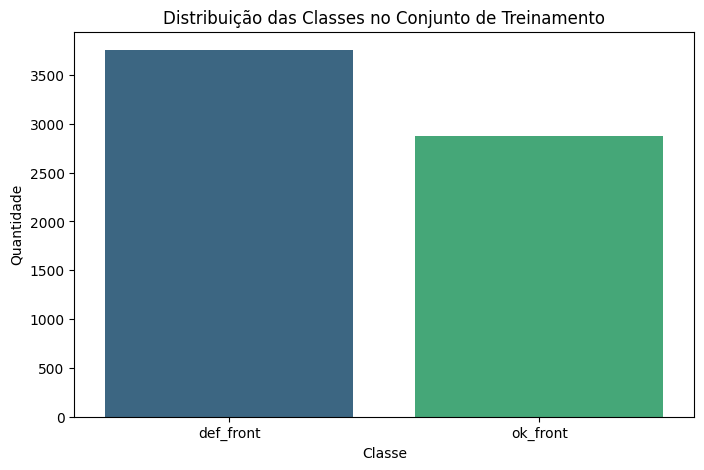

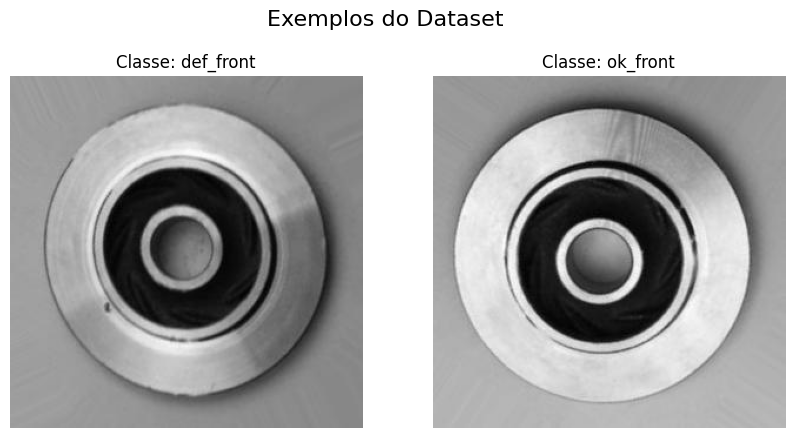

In [3]:
# Instalação e configuração do Kaggle no Colab (descomente se for rodar via API do Kaggle)
# !pip install -q kaggle
# from google.colab import files
# print("Faça o upload do seu kaggle.json:")
# files.upload()
# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d ravirajsinh45/real-life-industrial-dataset-of-casting-product
# !unzip -q real-life-industrial-dataset-of-casting-product.zip -d dataset/

# Diretório base
base_dir = 'dataset/casting_data/casting_data' # Ajuste o caminho conforme o seu ambiente
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

classes = ['def_front', 'ok_front']

# Função para contar arquivos e verificar dimensões
def explorar_dataset(diretorio):
    dados = []
    dimensoes = set()
    total = 0
    
    for cls in classes:
        caminho_cls = os.path.join(diretorio, cls)
        if not os.path.exists(caminho_cls):
            continue
            
        arquivos = os.listdir(caminho_cls)
        qtd = len(arquivos)
        total += qtd
        dados.append({'Classe': cls, 'Quantidade': qtd})
        
        # Verificar dimensões da primeira imagem de cada classe
        if qtd > 0:
            img_path = os.path.join(caminho_cls, arquivos[0])
            img = cv2.imread(img_path)
            if img is not None:
                dimensoes.add(img.shape)
                
    return pd.DataFrame(dados), total, dimensoes

try:
    df_train, total_train, dim_train = explorar_dataset(train_dir)
    df_test, total_test, dim_test = explorar_dataset(test_dir)

    print(f"Total de imagens de Treino: {total_train}")
    print(f"Total de imagens de Teste: {total_test}")
    print(f"Dimensões encontradas no treino: {dim_train}")

    # Plotar distribuição das classes no treino
    plt.figure(figsize=(8, 5))
    sns.barplot(data=df_train, x='Classe', y='Quantidade', palette='viridis')
    plt.title('Distribuição das Classes no Conjunto de Treinamento')
    plt.show()

    # Visualizar exemplos
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    for i, cls in enumerate(classes):
        img_path = os.path.join(train_dir, cls, os.listdir(os.path.join(train_dir, cls))[0])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img)
        axes[i].set_title(f'Classe: {cls}')
        axes[i].axis('off')
    plt.suptitle("Exemplos do Dataset", fontsize=16)
    plt.show()
except Exception as e:
    print(f"Aviso: Dataset não encontrado no diretório. Execute a célula de download do Kaggle primeiro. Erro: {e}")

Found 5307 images belonging to 2 classes.
Found 6633 images belonging to 2 classes.
Found 6633 images belonging to 2 classes.
Found 1326 images belonging to 2 classes.
Found 715 images belonging to 2 classes.
Found 5307 images belonging to 2 classes.
Found 6633 images belonging to 2 classes.
Found 1326 images belonging to 2 classes.
Found 715 images belonging to 2 classes.
Mapeamento das classes: {'def_front': 0, 'ok_front': 1}


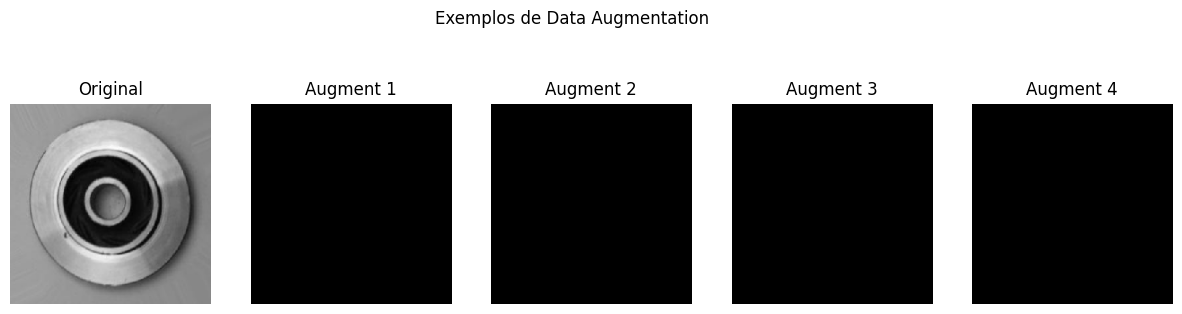

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# Treino da CNN própria: augmentation + normalização [0, 1].
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.20
)

# IMPORTANTE: validação não recebe augmentation.
val_datagen = ImageDataGenerator(rescale=1.0 / 255.0)
test_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

# Geradores específicos para MobileNetV2.
# MobileNetV2 espera preprocessing_input (pixels transformados para [-1, 1]).
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

tl_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.20
)
tl_val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
tl_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

if train_dir and test_dir:
    train_generator = train_datagen.flow_from_directory(
        train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode="binary", subset="training", seed=SEED, shuffle=True
    )
    val_generator = val_datagen.flow_from_directory(
        train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode="binary", subset=None, shuffle=False
    )

    # A validação deve ser exatamente os 20% reservados no treino.
    val_generator = tl_val_datagen.flow_from_directory(
        train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode="binary", subset=None, shuffle=False
    )

    # ImageDataGenerator com validation_split apenas para selecionar o subconjunto.
    val_selection_datagen = ImageDataGenerator(
        rescale=1.0 / 255.0, validation_split=0.20
    )
    val_generator = val_selection_datagen.flow_from_directory(
        train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode="binary", subset="validation", seed=SEED, shuffle=False
    )

    test_generator = test_datagen.flow_from_directory(
        test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode="binary", shuffle=False
    )

    tl_train_generator = tl_train_datagen.flow_from_directory(
        train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode="binary", subset="training", seed=SEED, shuffle=True
    )
    tl_val_generator = tl_val_datagen.flow_from_directory(
        train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode="binary", shuffle=False
    )
    tl_val_selection_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input, validation_split=0.20
    )
    tl_val_generator = tl_val_selection_datagen.flow_from_directory(
        train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode="binary", subset="validation", seed=SEED, shuffle=False
    )
    tl_test_generator = tl_test_datagen.flow_from_directory(
        test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode="binary", shuffle=False
    )

    print("Mapeamento das classes:", train_generator.class_indices)

    # Visualização do augmentation.
    arquivos_defeito = [
        f for f in os.listdir(os.path.join(train_dir, "def_front"))
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
    ]
    if arquivos_defeito:
        img_path = os.path.join(train_dir, "def_front", arquivos_defeito[0])
        img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
        img_array = tf.keras.utils.img_to_array(img)
        img_batch = np.expand_dims(img_array, axis=0)

        fig, axes = plt.subplots(1, 5, figsize=(15, 4))
        axes[0].imshow(img_array.astype("uint8"))
        axes[0].set_title("Original")
        axes[0].axis("off")

        aug_iter = train_datagen.flow(img_batch, batch_size=1, seed=SEED)
        for i in range(1, 5):
            batch = next(aug_iter)[0]
            axes[i].imshow(np.clip(batch / 255.0, 0, 1))
            axes[i].set_title(f"Augment {i}")
            axes[i].axis("off")
        plt.suptitle("Exemplos de Data Augmentation")
        plt.show()
else:
    print("Geradores não criados porque o dataset não foi localizado.")


Carregando conjunto de Treinamento:
Found 5307 images belonging to 2 classes.

Carregando conjunto de Validação:
Found 1326 images belonging to 2 classes.

Carregando conjunto de Teste:
Found 715 images belonging to 2 classes.


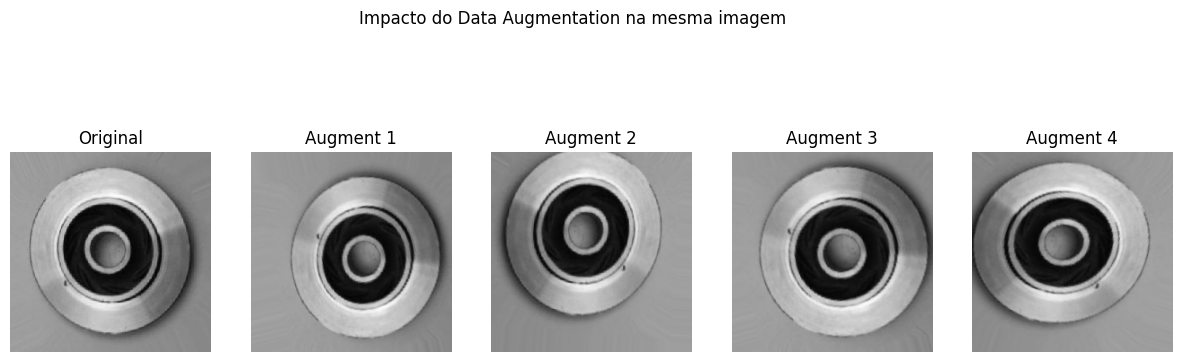

In [5]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Gerador para Treinamento COM Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalização de pixels (0 a 1)
    rotation_range=20,        # Rotação física na esteira
    width_shift_range=0.1,    # Deslocamento
    height_shift_range=0.1,
    zoom_range=0.1,           # Distância da câmera
    horizontal_flip=True,     # Simetria da peça
    vertical_flip=True,
    validation_split=0.2      # 20% do treino será validação
)

# Gerador para Teste (APENAS Normalização)
test_datagen = ImageDataGenerator(rescale=1./255)

try:
    print("Carregando conjunto de Treinamento:")
    train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary',
        subset='training',
        seed=42
    )

    print("\nCarregando conjunto de Validação:")
    val_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary',
        subset='validation',
        seed=42
    )

    print("\nCarregando conjunto de Teste:")
    test_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary',
        shuffle=False # Não embaralhar para manter ordem na avaliação
    )

    # Visualizando o efeito do Augmentation
    img_path = os.path.join(train_dir, 'def_front', os.listdir(os.path.join(train_dir, 'def_front'))[0])
    img_array = tf.keras.preprocessing.image.img_to_array(tf.keras.preprocessing.image.load_img(img_path, target_size=IMG_SIZE))
    img_array = img_array.reshape((1,) + img_array.shape)

    fig, axes = plt.subplots(1, 5, figsize=(15, 5))
    axes[0].imshow(img_array[0].astype('uint8') / 255.)
    axes[0].set_title('Original')
    axes[0].axis('off')

    i = 1
    for batch in train_datagen.flow(img_array, batch_size=1):
        axes[i].imshow(batch[0])
        axes[i].set_title(f'Augment {i}')
        axes[i].axis('off')
        i += 1
        if i == 5:
            break
    plt.suptitle("Impacto do Data Augmentation na mesma imagem")
    plt.show()
except Exception as e:
    print("Imagens não carregadas devido à falta do dataset no diretório.")

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,785 (432.75 KB)

 Trainable params: 110,337 (431.00 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/15
166/166 ━━━━━━━━━━━━━━━━━━━━ 454s 3s/step - accuracy: 0.7816 - loss: 0.4764 - precision: 0.7650 - recall: 0.7161 - val_accuracy: 0.6048 - val_loss: 0.6196 - val_precision: 0.9180 - val_recall: 0.0974
Epoch 2/15
166/166 ━━━━━━━━━━━━━━━━━━━━ 454s 3s/step - accuracy: 0.8347 - loss: 0.3851 - precision: 0.8114 - recall: 0.8061 - val_accuracy: 0.5664 - val_loss: 1.6070 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/15
166/166 ━━━━━━━━━━━━━━━━━━━━ 538s 3s/step - accuracy: 0.8656 - loss: 0.3245 - precision: 0.8428 - recall: 0.8483 - val_accuracy: 0.4336 - val_loss: 9.6072 - val_precision: 0.4336 - val_recall: 1.0000
Epoch 4/15
166/166 ━━━━━━━━━━━━━━━━━━━━ 516s 3s/step - accuracy: 0.9077 - loss: 0.2398 - precision: 0.8887 - recall: 0.8996 - val_accuracy: 0.4472 - val_loss: 1.6251 - val_precision: 0.4396 - val_recall: 1.0000
Epoch 5/15
166/166 ━━━━━━━━━━━━━━━━━━━━ 552s 3s/step - accuracy: 0.9145 - loss: 0.2178 - precision: 0.8985 - recall: 0.9048 - val_accuracy: 0.4336 -

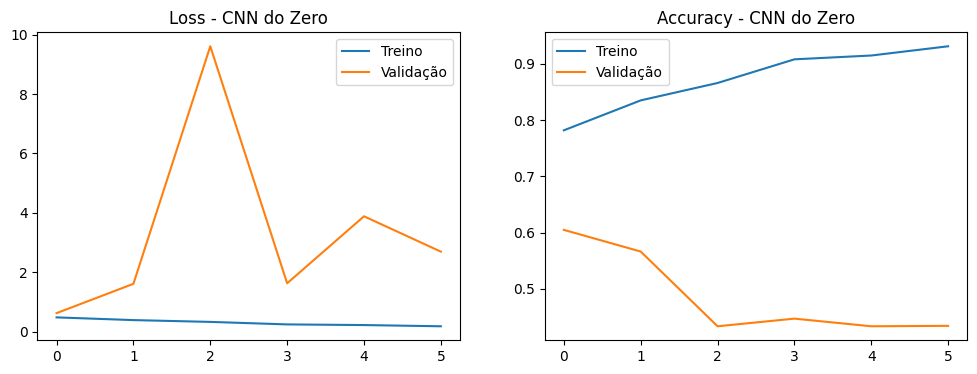

In [18]:
from tensorflow.keras import Input

def build_custom_cnn():
    model = Sequential([
        Input(shape=(*IMG_SIZE, 3)),
        Conv2D(32, (3, 3), activation="relu"),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Conv2D(64, (3, 3), activation="relu"),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Conv2D(128, (3, 3), activation="relu"),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        GlobalAveragePooling2D(),
        Dropout(0.5),
        Dense(128, activation="relu"),
        Dropout(0.3),
        Dense(1, activation="sigmoid")
    ])
    return model

model_cnn = build_custom_cnn()
model_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

model_cnn.summary()

callbacks_cnn = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ModelCheckpoint("best_custom_cnn.keras", save_best_only=True, monitor="val_loss")
]

def plot_history(history, title="Curvas de Treinamento"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history["loss"], label="Treino")
    axes[0].plot(history.history["val_loss"], label="Validação")
    axes[0].set_title(f"Loss - {title}")
    axes[0].legend()

    axes[1].plot(history.history["accuracy"], label="Treino")
    axes[1].plot(history.history["val_accuracy"], label="Validação")
    axes[1].set_title(f"Accuracy - {title}")
    axes[1].legend()
    plt.show()

# Altere para True quando quiser executar os treinamentos.
RUN_TRAINING = True

if RUN_TRAINING:
    if train_dir is None:
        raise FileNotFoundError("Dataset não encontrado.")
    history_cnn = model_cnn.fit(
        train_generator,
        validation_data=val_generator,
        epochs=15,
        callbacks=callbacks_cnn
    )
    plot_history(history_cnn, "CNN do Zero")


c:\Users\Administrator\Documents\PUC Minas\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,785 (432.75 KB)

 Trainable params: 110,337 (431.00 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/15
166/166 ━━━━━━━━━━━━━━━━━━━━ 468s 3s/step - accuracy: 0.7931 - loss: 0.4715 - precision: 0.7835 - recall: 0.7222 - val_accuracy: 0.7436 - val_loss: 0.5934 - val_precision: 0.6700 - val_recall: 0.8052
Epoch 2/15
166/166 ━━━━━━━━━━━━━━━━━━━━ 446s 3s/step - accuracy: 0.8466 - loss: 0.3750 - precision: 0.8236 - recall: 0.8222 - val_accuracy: 0.5573 - val_loss: 0.6734 - val_precision: 0.4947 - val_recall: 0.9722
Epoch 3/15
166/166 ━━━━━━━━━━━━━━━━━━━━ 451s 3s/step - accuracy: 0.8521 - loss: 0.3432 - precision: 0.8236 - recall: 0.8383 - val_accuracy: 0.6983 - val_loss: 0.5200 - val_precision: 0.9310 - val_recall: 0.3287
Epoch 4/15
166/166 ━━━━━━━━━━━━━━━━━━━━ 562s 3s/step - accuracy: 0.8713 - loss: 0.3025 - precision: 0.8454 - recall: 0.8604 - val_accuracy: 0.4336 - val_loss: 4.5710 - val_precision: 0.4336 - val_recall: 1.0000
Epoch 5/15
166/166 ━━━━━━━━━━━━━━━━━━━━ 450s 3s/step - accuracy: 0.8933 - loss: 0.2628 - precision: 0.8699 - recall: 0.8865 - val_accuracy: 0.4336 - val_los

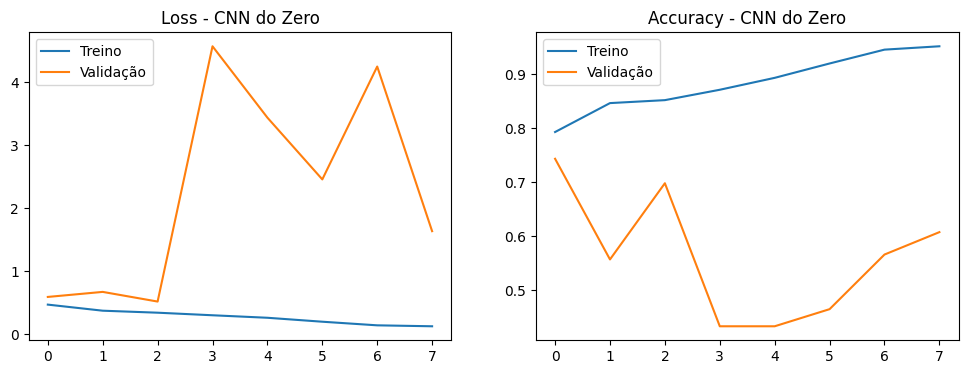

In [20]:
def build_custom_cnn():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3)),
        BatchNormalization(),
        MaxPooling2D(2,2),
        
        Conv2D(64, (3,3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2,2),
        
        Conv2D(128, (3,3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2,2),
        
        GlobalAveragePooling2D(),
        Dropout(0.5), # Regularização
        
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid') # Saída binária
    ])
    return model

model_cnn = build_custom_cnn()
model_cnn.compile(optimizer='adam', 
                  loss='binary_crossentropy', 
                  metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')])

model_cnn.summary()

# Callbacks para evitar desperdício de recurso e salvar o melhor modelo
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_custom_cnn.keras', save_best_only=True, monitor='val_loss')
]

def plot_history(history, title="Curvas de Treinamento"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].plot(history.history['loss'], label='Treino')
    axes[0].plot(history.history['val_loss'], label='Validação')
    axes[0].set_title(f'Loss - {title}')
    axes[0].legend()
    
    axes[1].plot(history.history['accuracy'], label='Treino')
    axes[1].plot(history.history['val_accuracy'], label='Validação')
    axes[1].set_title(f'Accuracy - {title}')
    axes[1].legend()
    plt.show()

# Descomente a linha abaixo para executar o treinamento caso o dataset esteja configurado
history_cnn = model_cnn.fit(train_generator, validation_data=val_generator, epochs=15, callbacks=callbacks)
plot_history(history_cnn, "CNN do Zero")


--- CNN do zero ---
              precision    recall  f1-score   support

   def_front       0.70      1.00      0.83       453
    ok_front       1.00      0.27      0.43       262

    accuracy                           0.73       715
   macro avg       0.85      0.64      0.63       715
weighted avg       0.81      0.73      0.68       715



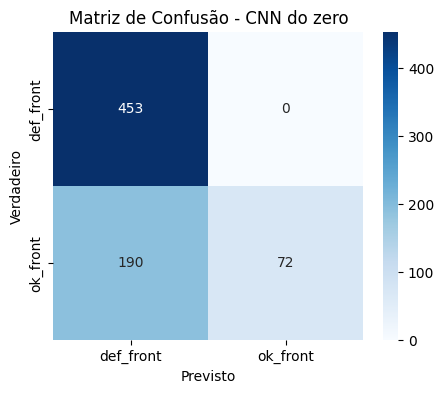

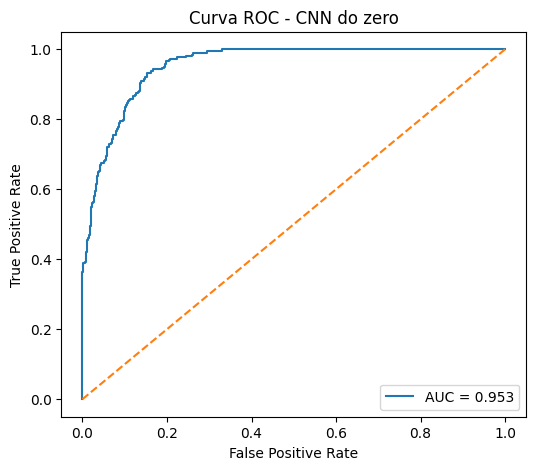

In [21]:
resultados = []

# Pelo class_indices padrão do flow_from_directory:
# def_front = 0 (defeito) e ok_front = 1 (OK).
def registrar_metricas(nome_modelo, y_true, y_pred, y_pred_prob, classes_ordenadas=None):
    classes_ordenadas = classes_ordenadas or classes
    report = classification_report(
        y_true, y_pred, output_dict=True, zero_division=0
    )
    auc = roc_auc_score(y_true, y_pred_prob)

    # Recall específico da classe 0 = recall de defeitos.
    recall_defeito = report.get("0", {}).get("recall", np.nan)

    resultados.append({
        "Modelo": nome_modelo,
        "Accuracy": report["accuracy"],
        "Precision_macro": report["macro avg"]["precision"],
        "Recall_macro": report["macro avg"]["recall"],
        "F1_macro": report["macro avg"]["f1-score"],
        "Recall_defeito": recall_defeito,
        "ROC-AUC": auc
    })

    print(f"\n--- {nome_modelo} ---")
    print(classification_report(
        y_true, y_pred, target_names=classes_ordenadas, zero_division=0
    ))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=classes_ordenadas, yticklabels=classes_ordenadas
    )
    plt.title(f"Matriz de Confusão - {nome_modelo}")
    plt.ylabel("Verdadeiro")
    plt.xlabel("Previsto")
    plt.show()

    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    plt.plot([0, 1], [0, 1], "--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"Curva ROC - {nome_modelo}")
    plt.legend()
    plt.show()

if RUN_TRAINING:
    y_true = test_generator.classes
    y_pred_prob_cnn = model_cnn.predict(test_generator, verbose=0).ravel()
    y_pred_cnn = (y_pred_prob_cnn >= 0.5).astype(int)
    registrar_metricas("CNN do zero", y_true, y_pred_cnn, y_pred_prob_cnn)


23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 350ms/step - accuracy: 0.7343 - loss: 0.4551 - precision: 1.0000 - recall: 0.2748
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 337ms/step

--- CNN do zero ---
              precision    recall  f1-score   support

   def_front       0.70      1.00      0.83       453
    ok_front       1.00      0.27      0.43       262

    accuracy                           0.73       715
   macro avg       0.85      0.64      0.63       715
weighted avg       0.81      0.73      0.68       715



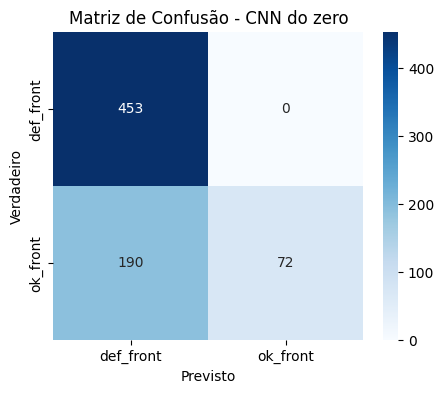

In [22]:
resultados = []

def registrar_metricas(nome_modelo, y_true, y_pred, y_pred_prob):
    report = classification_report(y_true, y_pred, output_dict=True)
    auc = roc_auc_score(y_true, y_pred_prob)
    resultados.append({
        'Modelo': nome_modelo,
        'Accuracy': report['accuracy'],
        'Precision': report['macro avg']['precision'],
        'Recall': report['macro avg']['recall'],
        'F1-score': report['macro avg']['f1-score'],
        'ROC-AUC': auc
    })
    
    print(f"\n--- {nome_modelo} ---")
    print(classification_report(y_true, y_pred, target_names=classes))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(f'Matriz de Confusão - {nome_modelo}')
    plt.ylabel('Verdadeiro')
    plt.xlabel('Previsto')
    plt.show()

cnn_eval = model_cnn.evaluate(test_generator)
y_pred_prob_cnn = model_cnn.predict(test_generator)
y_pred_cnn = (y_pred_prob_cnn > 0.5).astype(int).reshape(-1)
y_true = test_generator.classes
registrar_metricas("CNN do zero", y_true, y_pred_cnn, y_pred_prob_cnn)

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 175s 1s/step - accuracy: 0.7839 - loss: 0.4399 - precision: 0.7589 - recall: 0.7348 - val_accuracy: 0.9057 - val_loss: 0.2833 - val_precision: 0.8738 - val_recall: 0.9148
Epoch 2/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 165s 993ms/step - accuracy: 0.8926 - loss: 0.2652 - precision: 0.8659 - recall: 0.8900 - val_accuracy: 0.9336 - val_loss: 0.2130 - val_precision: 0.8959 - val_recall: 0.9583
Epoch 3/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 165s 993ms/step - accuracy: 0.9177 - loss: 0.2082 - precision: 0.8986 - recall: 0.9130 - val_accuracy: 0.9449 - val_loss: 0.1777 - val_precision: 0.9022 - val_recall: 0.9791
Epoch 4/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 168s 1s/step - accuracy: 0.9350 - loss: 0.1810 - precision: 0.9201 - recall: 0.9309 - val_accuracy: 0.9449 - val_loss: 0.1651 - val_precision: 0.8922 - val_recall: 0.9930
Epoch 5/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 165s 991ms/step - accuracy: 0.9391 - loss: 0.1694 - precision: 0.9219 - recall: 0.9391 - val_accuracy: 0.9646 

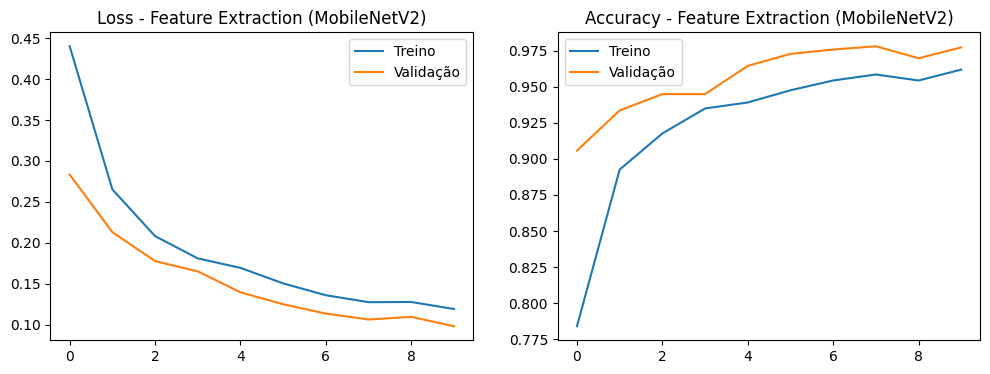


--- Feature Extraction ---
              precision    recall  f1-score   support

   def_front       0.99      0.98      0.98       453
    ok_front       0.96      0.98      0.97       262

    accuracy                           0.98       715
   macro avg       0.97      0.98      0.98       715
weighted avg       0.98      0.98      0.98       715



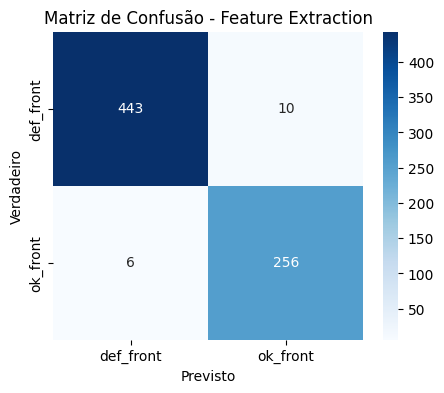

In [23]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(*IMG_SIZE, 3)
)
base_model.trainable = False

model_fe = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model_fe.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Precision(name="precision"),
             tf.keras.metrics.Recall(name="recall")]
)
model_fe.summary()

callbacks_fe = [
    EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    ModelCheckpoint("best_fe.keras", save_best_only=True, monitor="val_loss")
]

if RUN_TRAINING:
    history_fe = model_fe.fit(
        tl_train_generator,
        validation_data=tl_val_generator,
        epochs=10,
        callbacks=callbacks_fe
    )
    plot_history(history_fe, "Feature Extraction (MobileNetV2)")

    y_pred_prob_fe = model_fe.predict(tl_test_generator, verbose=0).ravel()
    y_pred_fe = (y_pred_prob_fe >= 0.5).astype(int)
    registrar_metricas("Feature Extraction", tl_test_generator.classes,
                       y_pred_fe, y_pred_prob_fe)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 190s 1s/step - accuracy: 0.8136 - loss: 0.4114 - val_accuracy: 0.9208 - val_loss: 0.2552
Epoch 2/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 180s 1s/step - accuracy: 0.9146 - loss: 0.2401 - val_accuracy: 0.9555 - val_loss: 0.1788
Epoch 3/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 180s 1s/step - accuracy: 0.9348 - loss: 0.1872 - val_accuracy: 0.9495 - val_loss: 0.1584
Epoch 4/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 180s 1s/step - accuracy: 0.9361 - loss: 0.1758 - val_accuracy: 0.9578 - val_loss: 0.1359
Epoch 5/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 179s 1s/step - accuracy: 0.9471 - loss: 0.1493 - val_accuracy: 0.9638 - val_loss: 0.1218
Epoch 6/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 173s 1s/step - accuracy: 0.9572 - loss: 0.1380 - val_accuracy: 0.9698 - val_loss: 0.1122
Epoch 7/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.9544 - loss: 0.1333 - val_accuracy: 0.9744 - val_loss: 0.1069
Epoch 8/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 177s 1s/step - accuracy: 0.9563 - loss: 0.1240 - val_accu

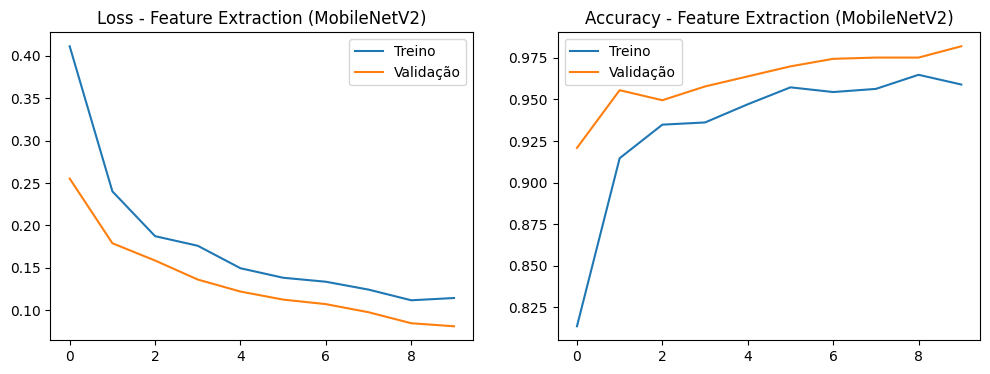

23/23 ━━━━━━━━━━━━━━━━━━━━ 17s 666ms/step

--- Feature Extraction ---
              precision    recall  f1-score   support

   def_front       0.98      0.99      0.98       453
    ok_front       0.98      0.96      0.97       262

    accuracy                           0.98       715
   macro avg       0.98      0.98      0.98       715
weighted avg       0.98      0.98      0.98       715



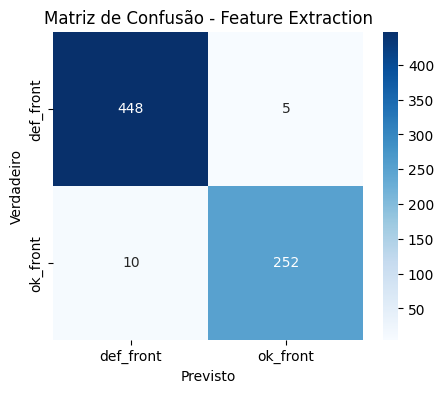

In [24]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False # Congela os pesos base

model_fe = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_fe.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_fe.summary()

callbacks_fe = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ModelCheckpoint('best_fe.keras', save_best_only=True, monitor='val_loss')
]

history_fe = model_fe.fit(train_generator, validation_data=val_generator, epochs=10, callbacks=callbacks_fe)
plot_history(history_fe, "Feature Extraction (MobileNetV2)")

y_pred_prob_fe = model_fe.predict(test_generator)
y_pred_fe = (y_pred_prob_fe > 0.5).astype(int).reshape(-1)
registrar_metricas("Feature Extraction", y_true, y_pred_fe, y_pred_prob_fe)

Epoch 1/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 213s 1s/step - accuracy: 0.9589 - loss: 0.1080 - precision: 0.9495 - recall: 0.9561 - val_accuracy: 0.9864 - val_loss: 0.0422 - val_precision: 0.9912 - val_recall: 0.9774
Epoch 2/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 203s 1s/step - accuracy: 0.9813 - loss: 0.0595 - precision: 0.9766 - recall: 0.9804 - val_accuracy: 0.9925 - val_loss: 0.0260 - val_precision: 0.9879 - val_recall: 0.9948
Epoch 3/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 260s 1s/step - accuracy: 0.9885 - loss: 0.0367 - precision: 0.9844 - recall: 0.9891 - val_accuracy: 0.9917 - val_loss: 0.0317 - val_precision: 0.9812 - val_recall: 1.0000
Epoch 4/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 203s 1s/step - accuracy: 0.9917 - loss: 0.0323 - precision: 0.9866 - recall: 0.9943 - val_accuracy: 0.9940 - val_loss: 0.0206 - val_precision: 0.9880 - val_recall: 0.9983
Epoch 5/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.9934 - loss: 0.0227 - precision: 0.9896 - recall: 0.9952 - val_accuracy: 0.9917 - val_los

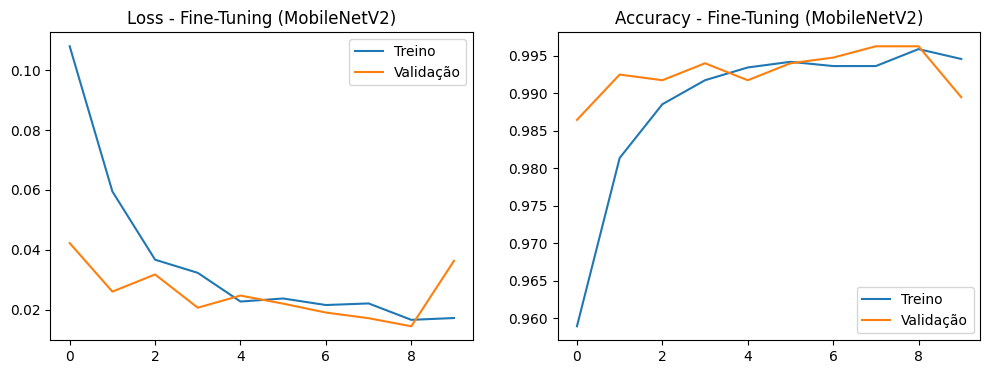


--- Fine-tuning ---
              precision    recall  f1-score   support

   def_front       1.00      1.00      1.00       453
    ok_front       0.99      0.99      0.99       262

    accuracy                           0.99       715
   macro avg       0.99      0.99      0.99       715
weighted avg       0.99      0.99      0.99       715



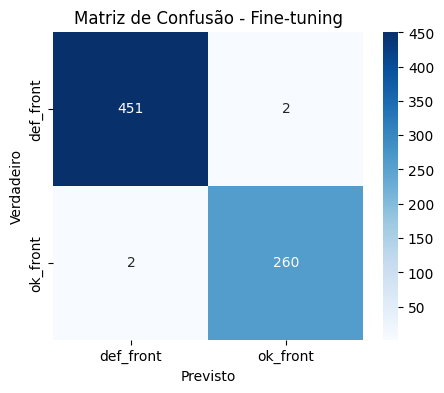

In [25]:
# Partimos do modelo usado no Feature Extraction.
base_model.trainable = True

# Congela as primeiras camadas e mantém BatchNormalization congelada.
for layer in base_model.layers[:100]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False

model_fe.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Precision(name="precision"),
             tf.keras.metrics.Recall(name="recall")]
)

callbacks_ft = [
    EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    ModelCheckpoint("best_ft.keras", save_best_only=True, monitor="val_loss")
]

if RUN_TRAINING:
    history_ft = model_fe.fit(
        tl_train_generator,
        validation_data=tl_val_generator,
        epochs=10,
        callbacks=callbacks_ft
    )
    plot_history(history_ft, "Fine-Tuning (MobileNetV2)")

    y_pred_prob_ft = model_fe.predict(tl_test_generator, verbose=0).ravel()
    y_pred_ft = (y_pred_prob_ft >= 0.5).astype(int)
    registrar_metricas("Fine-tuning", tl_test_generator.classes,
                       y_pred_ft, y_pred_prob_ft)


In [1]:
# Descongelando o modelo base
base_model.trainable = True

# Congelando as primeiras 100 camadas
for layer in base_model.layers[:100]:
    layer.trainable = False

# Learning Rate MUITO menor (ex: 1e-5) para evitar destruir os pesos
model_fe.compile(optimizer=tf.keras.optimizers.Adam(1e-5), 
                 loss='binary_crossentropy', 
                 metrics=['accuracy'])

callbacks_ft = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ModelCheckpoint('best_ft.keras', save_best_only=True, monitor='val_loss')
]

history_ft = model_fe.fit(train_generator, validation_data=val_generator, epochs=10, callbacks=callbacks_ft)
plot_history(history_ft, "Fine-Tuning (MobileNetV2)")


y_pred_prob_ft = model_fe.predict(test_generator)
y_pred_ft = (y_pred_prob_ft > 0.5).astype(int).reshape(-1)
registrar_metricas("Fine-tuning", y_true, y_pred_ft, y_pred_prob_ft)

NameError: name 'base_model' is not defined

In [14]:
if resultados:
    df_resultados = pd.DataFrame(resultados)
    display(df_resultados)

    ax = df_resultados.set_index("Modelo")[
        ["Recall_defeito", "F1_macro", "Accuracy"]
    ].plot(kind="bar", figsize=(10, 5))
    ax.set_title("Comparação dos Modelos")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    plt.xticks(rotation=0)
    plt.show()
else:
    print("Nenhum resultado disponível. Execute os treinamentos com RUN_TRAINING = True.")


Nenhum resultado disponível. Execute os treinamentos com RUN_TRAINING = True.


In [ ]:
df_resultados = pd.DataFrame(resultados)
display(df_resultados)

df_resultados.set_index('Modelo')[['Recall', 'F1-score', 'Accuracy']].plot(kind='bar', figsize=(10,5), colormap='Set2')
plt.title("Comparação de Métricas entre os Modelos")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.show()

In [16]:
def exibir_erros(indices, titulo, test_gen, y_true, y_prob, limite=6):
    if len(indices) == 0:
        print(f"Não houve ocorrências para: {titulo}")
        return

    limite = min(len(indices), limite)
    fig, axes = plt.subplots(1, limite, figsize=(4 * limite, 4))
    axes = np.atleast_1d(axes)

    for i, idx in enumerate(indices[:limite]):
        img = cv2.imread(test_gen.filepaths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        prob_ok = float(y_prob[idx])
        axes[i].imshow(img)
        axes[i].set_title(
            f"Prob. OK: {prob_ok:.3f}\n"
            f"Real: {classes[y_true[idx]]}\n"
            f"Pred: {classes[int(prob_ok >= 0.5)]}"
        )
        axes[i].axis("off")

    plt.suptitle(titulo)
    plt.tight_layout()
    plt.show()

if RUN_TRAINING:
    # Com def_front=0 e ok_front=1:
    # FN = defeito real (0) classificado como OK (1).
    fn_indices = np.where((y_true == 0) & (y_pred_ft == 1))[0]
    exibir_erros(
        fn_indices,
        "Falsos Negativos: defeito classificado como OK",
        tl_test_generator, y_true, y_pred_prob_ft
    )

    # FP = OK real (1) classificado como defeito (0).
    fp_indices = np.where((y_true == 1) & (y_pred_ft == 0))[0]
    exibir_erros(
        fp_indices,
        "Falsos Positivos: OK classificado como defeito",
        tl_test_generator, y_true, y_pred_prob_ft
    )
else:
    print("Execute o treinamento do Fine-Tuning para analisar os erros.")


Execute o treinamento do Fine-Tuning para analisar os erros.


In [ ]:
label_map = {v: k for k, v in test_generator.class_indices.items()}

def exibir_erros(indices, titulo, limite=3):
    if len(indices) == 0:
        print(f"Não houve ocorrências para: {titulo}")
        return
    
    limite = min(len(indices), limite)
    fig, axes = plt.subplots(1, limite, figsize=(15, 5))
    if limite == 1: axes = [axes]
    
    for i, idx in enumerate(indices[:limite]):
        img = cv2.imread(test_generator.filepaths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        prob = y_pred_prob_ft[idx][0]
        
        axes[i].imshow(img)
        axes[i].set_title(f"Prob: {prob:.3f}\nReal: {label_map[y_true[idx]]}")
        axes[i].axis('off')
    plt.suptitle(titulo)
    plt.show()

fn_indices = np.where((y_true == 0) & (y_pred_ft == 1))[0]
exibir_erros(fn_indices, "Falsos Negativos Críticos (Defeito classificado como OK)")

fp_indices = np.where((y_true == 1) & (y_pred_ft == 0))[0]
exibir_erros(fp_indices, "Falsos Positivos (OK classificado como Defeito)")

'\nlabel_map = {v: k for k, v in test_generator.class_indices.items()}\n\ndef exibir_erros(indices, titulo, limite=3):\n    if len(indices) == 0:\n        print(f"Não houve ocorrências para: {titulo}")\n        return\n\n    limite = min(len(indices), limite)\n    fig, axes = plt.subplots(1, limite, figsize=(15, 5))\n    if limite == 1: axes = [axes]\n\n    for i, idx in enumerate(indices[:limite]):\n        img = cv2.imread(test_generator.filepaths[idx])\n        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)\n        prob = y_pred_prob_ft[idx][0]\n\n        axes[i].imshow(img)\n        axes[i].set_title(f"Prob: {prob:.3f}\nReal: {label_map[y_true[idx]]}")\n        axes[i].axis(\'off\')\n    plt.suptitle(titulo)\n    plt.show()\n\nfn_indices = np.where((y_true == 0) & (y_pred_ft == 1))[0]\nexibir_erros(fn_indices, "Falsos Negativos Críticos (Defeito classificado como OK)")\n\nfp_indices = np.where((y_true == 1) & (y_pred_ft == 0))[0]\nexibir_erros(fp_indices, "Falsos Positivos (OK classif

### 18. Conclusão Acadêmica

Os resultados obtidos mostraram que o uso de Transfer Learning com a MobileNetV2 apresentou um desempenho bem superior ao da CNN treinada do zero para realizar a inspeção visual das peças industriais.

A CNN treinada do zero apresentou uma acurácia de 73% no conjunto de teste. Apesar de ter alcançado um recall de 1,00 para a classe `def_front`, apresentou um recall de apenas 0,27 para `ok_front`. Isso mostra que o modelo teve dificuldade para identificar corretamente as peças que não apresentavam defeitos, classificando várias delas como defeituosas. O F1-score macro foi de aproximadamente 0,63, indicando um desempenho desequilibrado entre as duas classes.

Já utilizando a estratégia de Feature Extraction com a MobileNetV2, foi possível obter uma melhora significativa, chegando a 98% de acurácia. Para a classe `def_front`, o modelo apresentou precision de 0,99, recall de 0,98 e F1-score de 0,98. Para `ok_front`, os resultados foram precision de 0,96, recall de 0,98 e F1-score de 0,97. O F1-score macro também ficou em aproximadamente 0,98, mostrando que o modelo conseguiu apresentar um desempenho mais equilibrado entre as classes.

O melhor resultado foi obtido utilizando o Fine-tuning da MobileNetV2, que alcançou 99% de acurácia. Para a classe `def_front`, foram obtidos precision, recall e F1-score de 1,00. Já para `ok_front`, os valores ficaram em 0,99 para as três métricas. O F1-score macro de 0,99 demonstra que o modelo apresentou um desempenho bastante equilibrado na classificação.

A partir desses resultados, foi possível perceber a importância do conhecimento prévio da MobileNetV2. Enquanto a CNN treinada do zero apresentou um desempenho mais limitado, o uso do modelo pré-treinado permitiu obter resultados muito melhores. O Feature Extraction já apresentou uma melhora significativa e, com o Fine-tuning, foi possível adaptar ainda mais o modelo às características específicas das imagens utilizadas no projeto.

No contexto industrial, considero o recall da classe defeituosa (`def_front`) uma das métricas mais importantes, pois um falso negativo significa classificar uma peça com defeito como uma peça adequada. Nesse caso, o Fine-tuning apresentou um recall de 1,00 para essa classe, o que indica que todas as peças defeituosas do conjunto de teste foram identificadas corretamente pelo modelo.

Mesmo com os resultados obtidos, acredito que ainda seriam necessárias outras validações antes de utilizar o modelo em uma linha de produção real. Seria importante testar o modelo com novas imagens, manter condições controladas de iluminação e posicionamento das peças, analisar os falsos positivos e falsos negativos e verificar se o desempenho se mantém ao longo do tempo. Também seria necessário considerar o custo de cada tipo de erro para definir o melhor limiar de classificação.

Dessa forma, considerando os resultados deste experimento, o Fine-tuning da MobileNetV2 foi a melhor estratégia entre as três abordadas. O modelo apresentou a maior acurácia, o melhor F1-score e um excelente desempenho na identificação das peças defeituosas. Com isso, o trabalho demonstrou que o uso de Transfer Learning pode ser uma alternativa eficiente para desenvolver sistemas de visão computacional voltados para inspeção automática de qualidade.